# SPOmiAlign Demo: Image to Image Section Alignment

This notebook follows a fixed workflow:
1. Input unaligned slices (paired images)
2. Imaging (generation of spatial structural images, SSI)
3. Sections matching and warpping
4. Reassignment
5. Output aligned slices


## 1. Input unaligned slices (paired images)

In [1]:
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np



# Resolve repo-relative imports so the notebook can run from any demo subfolder.
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents)
    if (candidate / "SPOmiAlign").is_dir()
)
DEMO_DIR = PROJECT_ROOT / "demo"
sys.path.append(str(PROJECT_ROOT / "SPOmiAlign"))

from roma import align_and_process_images

# This notebook aligns 092 to Puck_Num_57:
# fixed image = Puck_Num_57, moving image = 092.
source_candidates = [
    Path(os.environ.get("SPOMIALIGN_092_SOURCE", "")) if os.environ.get("SPOMIALIGN_092_SOURCE") else None,
    Path("/storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_image/092.png"),
    DEMO_DIR / "SPOmiAlign_Repro" / "output_image" / "092.png",
]
target_candidates = [
    Path(os.environ.get("SPOMIALIGN_PUCK57_TARGET", "")) if os.environ.get("SPOMIALIGN_PUCK57_TARGET") else None,
    Path("/storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_image/Puck_Num_57.png"),
    DEMO_DIR / "SPOmiAlign_Repro" / "output_image" / "Puck_Num_57.png",
]

def _first_existing(candidates):
    for path in candidates:
        if path is not None and Path(path).expanduser().exists():
            return Path(path).expanduser()
    return None

# img1 is the fixed reference image, img2 is the moving source image.
img2_path = _first_existing(source_candidates)
img1_path = _first_existing(target_candidates)
assert img1_path is not None, "Target image not found."
assert img2_path is not None, "Source image not found."

SAVE_ROOT = Path(os.environ.get("SPOMIALIGN_DEMO_SAVE_DIR", DEMO_DIR / "output")).expanduser()
SAVE_PATH = SAVE_ROOT / "img_2_img" / "092_to_Puck57"
SAVE_PATH.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {SAVE_PATH}")
print(f"Target image (fixed): {img1_path}")
print(f"Source image (moving): {img2_path}")


Output directory: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/img_2_img/092_to_Puck57
Target image (fixed): /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_image/Puck_Num_57.png
Source image (moving): /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_image/092.png


## 2. Imaging (generation of spatial structural images, SSI)

This notebook starts from prepared images, so no extra SSI generation step is required.


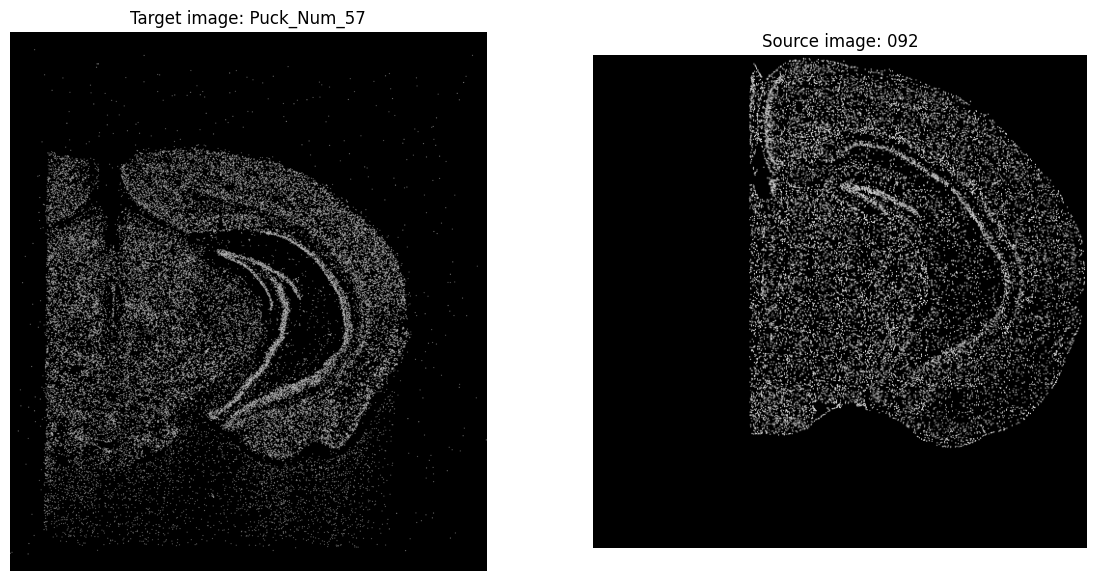

In [2]:
%matplotlib inline
# This demo starts from prepared images, so SSI generation is just visual inspection here.
print("This notebook starts from prepared images, so no extra SSI generation step is required.")

target_img = cv2.imread(str(img1_path), cv2.IMREAD_COLOR)
source_img = cv2.imread(str(img2_path), cv2.IMREAD_COLOR)
assert target_img is not None, f"Failed to read target image: {img1_path}"
assert source_img is not None, f"Failed to read source image: {img2_path}"

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Target image: Puck_Num_57")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(source_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Source image: 092")
axes[1].axis("off")
plt.show()


## 3. Sections matching and warpping

Using device: cuda:0


2026-04-13 01:00:16.447 | INFO     | romatch.models.model_zoo.roma_models:roma_model:61 - Using coarse resolution (560, 560), and upsample res (864, 1152)


Running RoMa matching...
Estimating affine+bspline transform...
Warping images...
Padding fill color: (255, 255, 255)


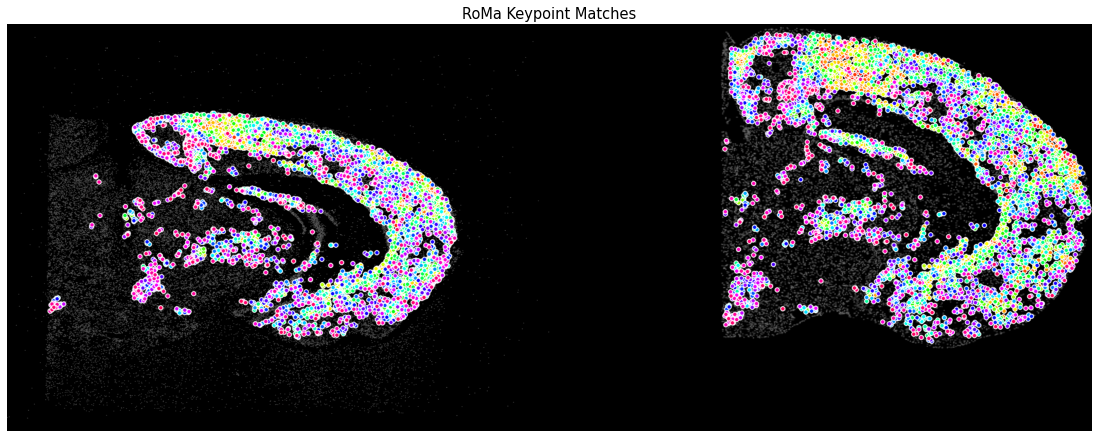

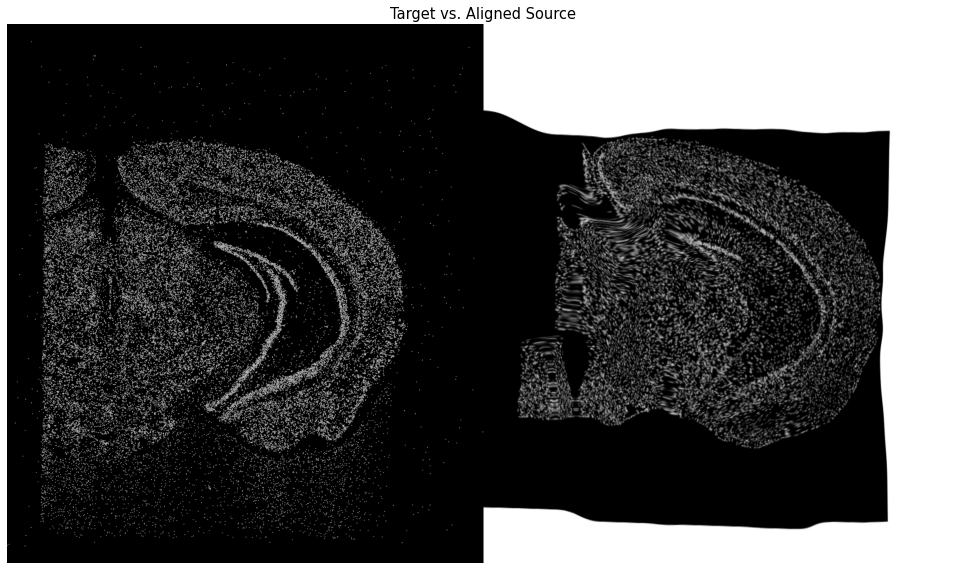

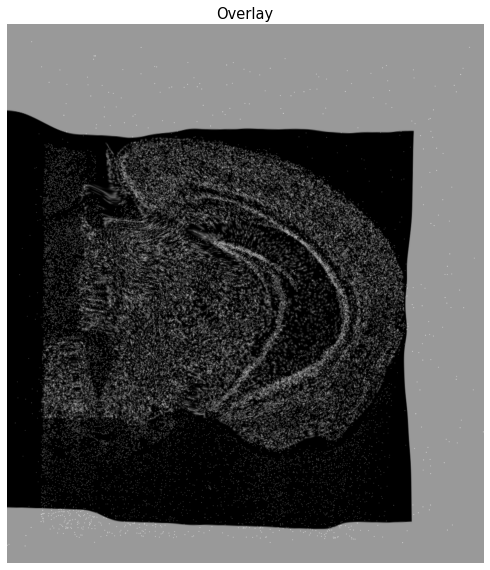

Alignment runtime: 9.9984 seconds
Done. Results saved to /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/img_2_img/092_to_Puck57/alignment


In [3]:
# Run image-to-image alignment with the same core flow as align_puck_to_reference_images.py.
save_path_alignment = SAVE_PATH / "alignment"
save_path_alignment.mkdir(parents=True, exist_ok=True)

align_and_process_images(
    img1_path=str(img1_path),
    img2_path=str(img2_path),
    h5ad_path=None,
    method="affine+bspline",
    output_dir=str(save_path_alignment),
    rotate=0.0,
    scale=1.0,
    auto_upscale_reference=False,
)


## 4. Reassignment

In [4]:
# No reassignment step here because this workflow only aligns two images.
print("Reassignment is not used in this notebook because it aligns images only.")


Reassignment is not used in this notebook because it aligns images only.


## 5. Output aligned slices

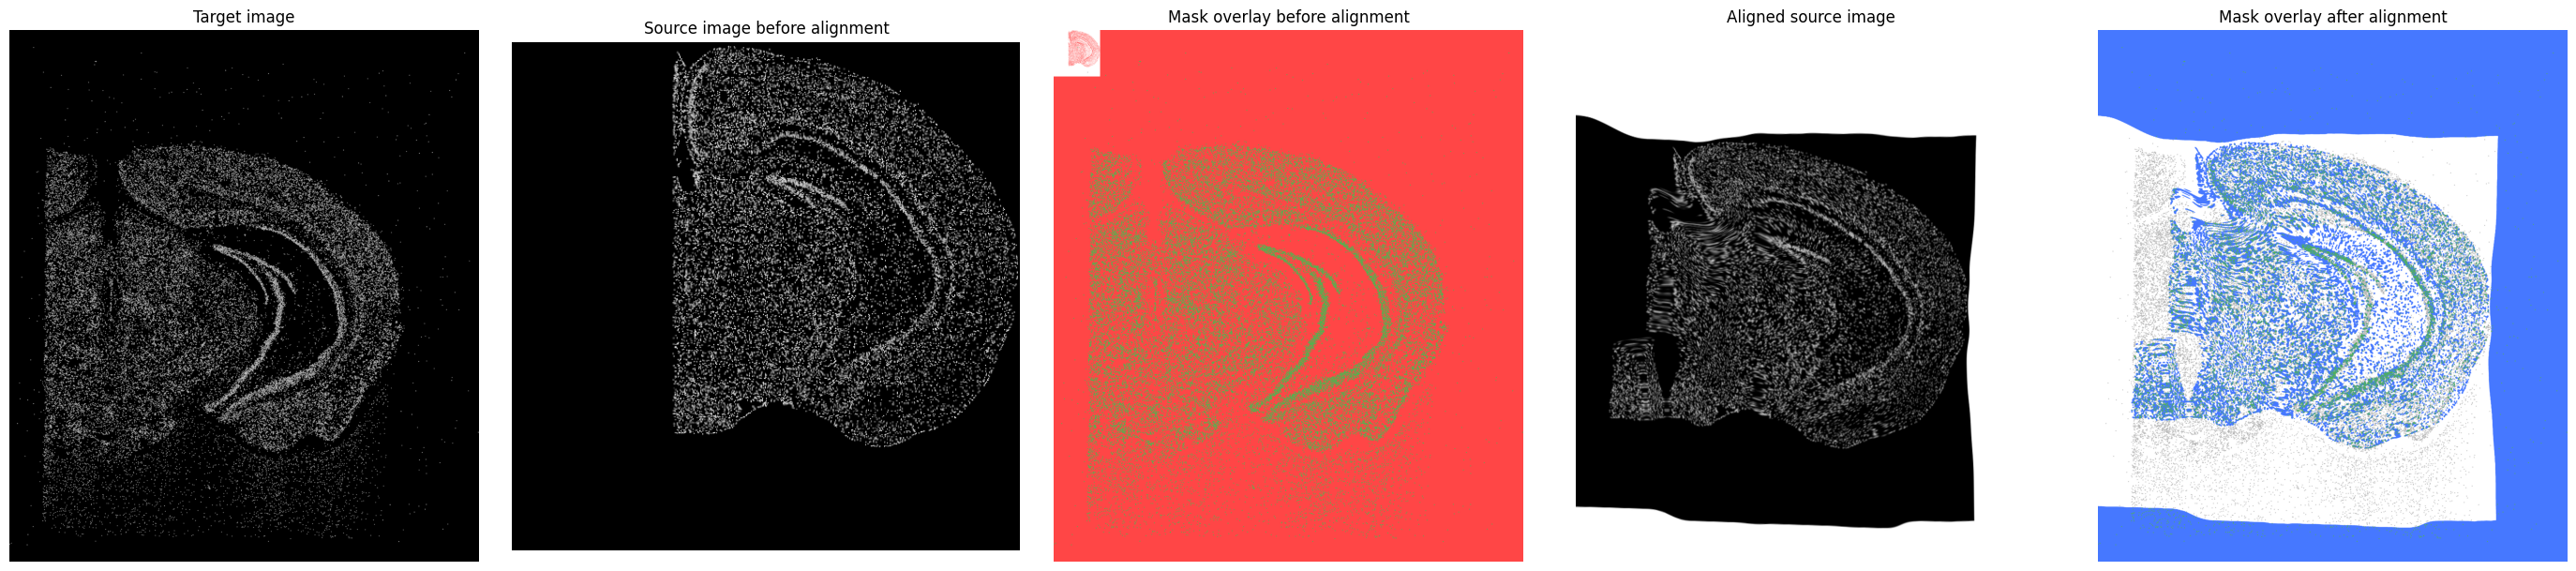

Aligned source image: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/img_2_img/092_to_Puck57/alignment/aligned_source_img2.png
Before overlay: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/img_2_img/092_to_Puck57/alignment/overlay_before_alignment.png
After overlay: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/img_2_img/092_to_Puck57/alignment/overlay_after_alignment.png


In [5]:
# Pad source/aligned images to the target canvas before blending, so the overlays are comparable.
# Build foreground-mask overlays instead of blending two full white-background images.
# Gray = target foreground, red = moving foreground, green = overlap.
aligned_source_path = save_path_alignment / "aligned_source_img2.png"
assert aligned_source_path.exists(), f"Aligned source image not found: {aligned_source_path}"

aligned_img = cv2.imread(str(aligned_source_path), cv2.IMREAD_COLOR)
assert aligned_img is not None, f"Failed to read aligned source image: {aligned_source_path}"

ref_h, ref_w = target_img.shape[:2]
mov_h, mov_w = source_img.shape[:2]
aligned_h, aligned_w = aligned_img.shape[:2]

source_canvas = np.full((ref_h, ref_w, 3), 255, dtype=np.uint8)
source_canvas[: min(ref_h, mov_h), : min(ref_w, mov_w)] = source_img[: min(ref_h, mov_h), : min(ref_w, mov_w)]
aligned_canvas = np.full((ref_h, ref_w, 3), 255, dtype=np.uint8)
aligned_canvas[: min(ref_h, aligned_h), : min(ref_w, aligned_w)] = aligned_img[: min(ref_h, aligned_h), : min(ref_w, aligned_w)]

def _foreground_mask(image, threshold=32):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return gray > threshold

def _mask_overlay(target_image, moving_image, moving_bgr, threshold=32):
    target_mask = _foreground_mask(target_image, threshold=threshold)
    moving_mask = _foreground_mask(moving_image, threshold=threshold)
    overlap_mask = target_mask & moving_mask

    canvas = np.full_like(target_image, 255)
    canvas[target_mask] = [180, 180, 180]
    canvas[moving_mask] = moving_bgr
    canvas[overlap_mask] = [80, 180, 80]
    return canvas

before_overlay = _mask_overlay(target_img, source_canvas, moving_bgr=[70, 70, 255])
after_overlay = _mask_overlay(target_img, aligned_canvas, moving_bgr=[255, 120, 70])

before_overlay_path = save_path_alignment / "overlay_before_alignment.png"
after_overlay_path = save_path_alignment / "overlay_after_alignment.png"
cv2.imwrite(str(before_overlay_path), before_overlay)
cv2.imwrite(str(after_overlay_path), after_overlay)

fig, axes = plt.subplots(1, 5, figsize=(28, 6))
axes[0].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Target image")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(source_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Source image before alignment")
axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(before_overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title("Mask overlay before alignment")
axes[2].axis("off")
axes[3].imshow(cv2.cvtColor(aligned_img, cv2.COLOR_BGR2RGB))
axes[3].set_title("Aligned source image")
axes[3].axis("off")
axes[4].imshow(cv2.cvtColor(after_overlay, cv2.COLOR_BGR2RGB))
axes[4].set_title("Mask overlay after alignment")
axes[4].axis("off")
plt.tight_layout()
plt.show()

print(f"Aligned source image: {aligned_source_path}")
print(f"Before overlay: {before_overlay_path}")
print(f"After overlay: {after_overlay_path}")
